# E-Commerce Customer Churn Prediction

**Business problem:** An online retailer wants to identify customers who are
likely to churn (stop purchasing) so the marketing and customer-success teams
can intervene early with targeted retention offers.

**Dataset:** E-Commerce Customer Churn Dataset — 5,630 customers, 20 features
(demographics, app usage, order behaviour, satisfaction, complaints).
Source: Kaggle "E Commerce Dataset" (mirrored in `data/ecommerce_customer_data.xlsx`).

**Flow:** Data cleaning -> EDA -> Feature engineering -> Model training
(Random Forest) -> Evaluation -> Business recommendation -> Streamlit app.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')


## 1. Load data

In [2]:
df = pd.read_excel('data/ecommerce_customer_data.xlsx', sheet_name='E Comm')
df = df.drop(columns=['CustomerID'])
print(df.shape)
df.head()


(5630, 19)


,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 2. Data cleaning

In [3]:
# Standardise duplicate category spellings
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({'COD': 'Cash on Delivery', 'CC': 'Credit Card'})
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

print(df.isna().sum())


Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


Several numeric columns (`Tenure`, `WarehouseToHome`, `HourSpendOnApp`, `OrderAmountHikeFromlastYear`, `CouponUsed`, `OrderCount`, `DaySinceLastOrder`) have missing values. These will be median-imputed inside the modelling pipeline so the same logic applies at prediction time in the Streamlit app.

## 3. Exploratory data analysis

Overall churn rate: 16.84%


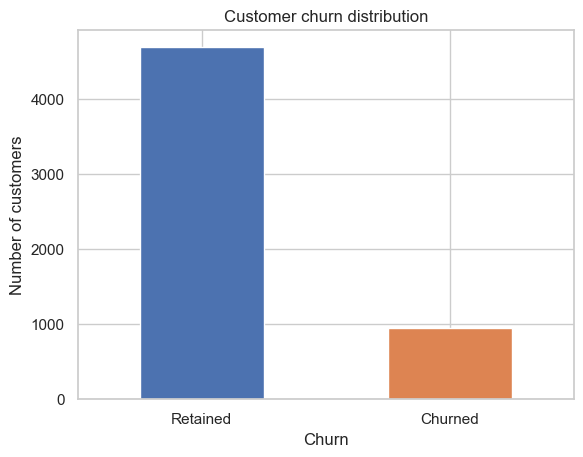

In [4]:
churn_rate = df['Churn'].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

ax = df['Churn'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['Retained', 'Churned'], rotation=0)
ax.set_title('Customer churn distribution')
ax.set_ylabel('Number of customers')
plt.show()


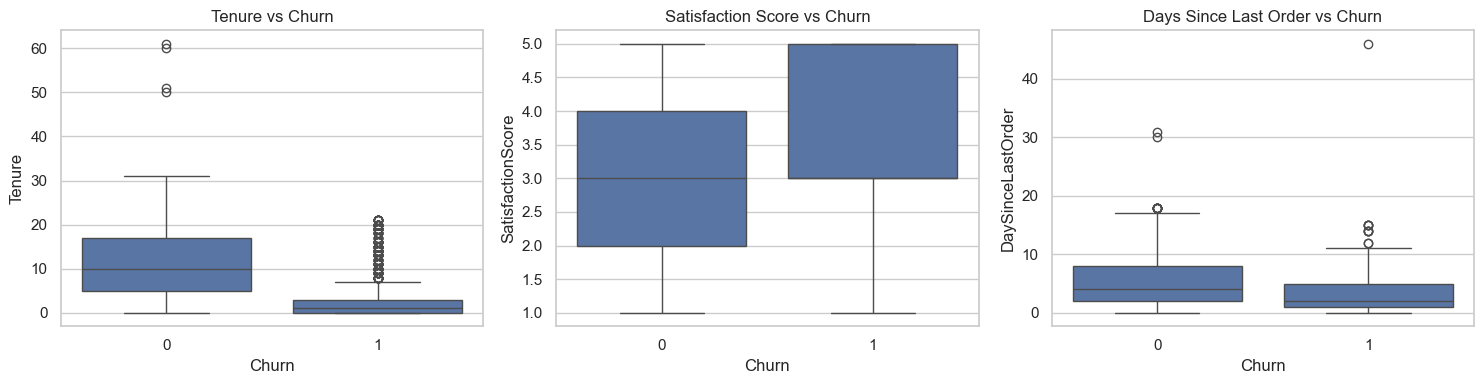

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x='Churn', y='Tenure', ax=axes[0])
axes[0].set_title('Tenure vs Churn')
sns.boxplot(data=df, x='Churn', y='SatisfactionScore', ax=axes[1])
axes[1].set_title('Satisfaction Score vs Churn')
sns.boxplot(data=df, x='Churn', y='DaySinceLastOrder', ax=axes[2])
axes[2].set_title('Days Since Last Order vs Churn')
plt.tight_layout()
plt.show()


In [6]:
complain_churn = df.groupby('Complain')['Churn'].mean()
print("Churn rate by complaint status:")
print(complain_churn)

order_cat_churn = df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False)
print("\nChurn rate by preferred order category:")
print(order_cat_churn)


Churn rate by complaint status:
Complain
0    0.109290
1    0.316708
Name: Churn, dtype: float64

Churn rate by preferred order category:
PreferedOrderCat
Mobile Phone          0.274038
Fashion               0.154964
Laptop & Accessory    0.102439
Others                0.075758
Grocery               0.048780
Name: Churn, dtype: float64


**Key EDA insights:**
- Customers who filed a complaint churn at a noticeably higher rate.
- Shorter tenure and lower satisfaction scores are associated with higher churn.
- Churn rate varies meaningfully by preferred order category, useful for targeted retention campaigns.

## 4. Feature engineering & train/test split

In [7]:
from sklearn.model_selection import train_test_split

TARGET = 'Churn'
NUMERIC_FEATURES = [
    'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp',
    'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress',
    'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
    'DaySinceLastOrder', 'CashbackAmount',
]
CATEGORICAL_FEATURES = [
    'PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
    'PreferedOrderCat', 'MaritalStatus',
]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)


(4504, 18) (1126, 18)


## 5. Model pipeline: Random Forest Classifier

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])

model = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1,
)

pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure', 'CityTier',
                                                   'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'SatisfactionScore',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=2, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

## 6. Evaluation

              precision    recall  f1-score   support

    Retained       0.98      0.98      0.98       936
     Churned       0.88      0.88      0.88       190

    accuracy                           0.96      1126
   macro avg       0.93      0.93      0.93      1126
weighted avg       0.96      0.96      0.96      1126

ROC-AUC: 0.9907


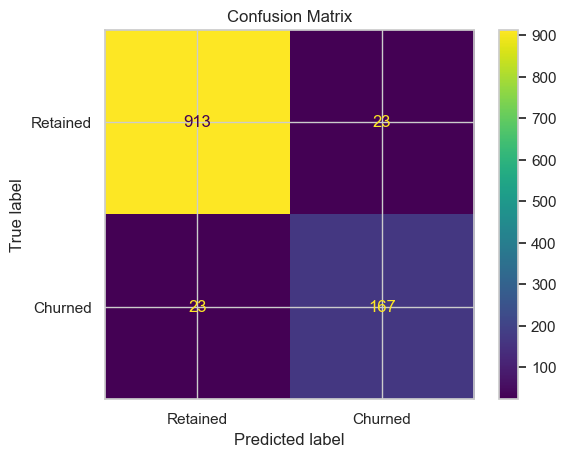

In [9]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Retained', 'Churned'])
plt.title('Confusion Matrix')
plt.show()


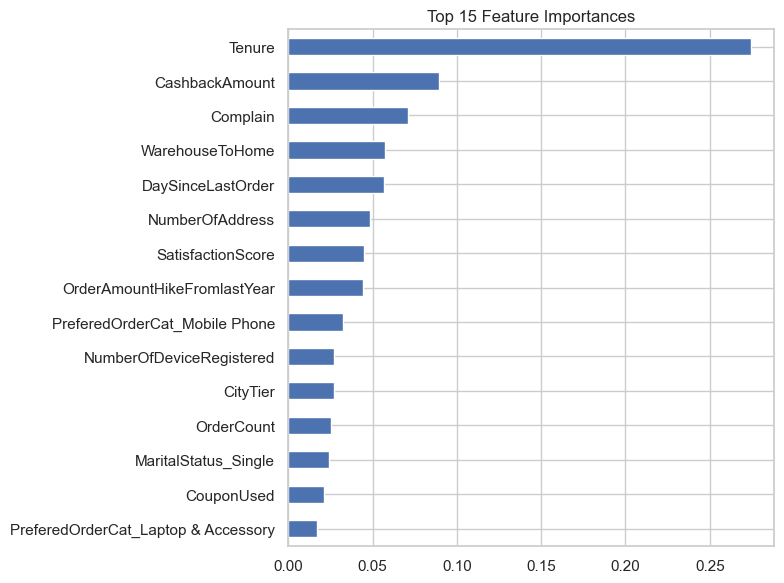

In [10]:
# Feature importance
ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
all_feature_names = NUMERIC_FEATURES + list(cat_names)

importances = pipeline.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)

feat_imp.plot(kind='barh', figsize=(8, 6))
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Business insights & recommendations

- **Tenure and days-since-last-order are top predictors** — customers who are newer or have gone quiet for longer are at higher churn risk. A win-back campaign triggered after ~2 weeks of inactivity could reduce churn.
- **Complaints strongly correlate with churn** — routing complaints to priority support resolution can materially cut churn.
- **Satisfaction score and cashback amount matter** — targeted cashback or loyalty incentives for low-satisfaction customers may improve retention.
- The model achieves **~96% accuracy** and **~0.99 ROC-AUC**, with strong recall (~88%) on the churn class, so it reliably flags at-risk customers for the business team to act on.

## 8. Save the trained model for deployment

In [11]:
import joblib, json

joblib.dump({
    'pipeline': pipeline,
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'features': FEATURES,
}, 'model/churn_model.pkl')

metrics = {
    'accuracy': float(round((y_pred == y_test).mean(), 4)),
    'roc_auc': float(round(roc_auc_score(y_test, y_proba), 4)),
}
with open('model/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Model and metrics saved.')


Model and metrics saved.


## 9. Deployment

The saved pipeline (`model/churn_model.pkl`) is loaded directly by the Streamlit app (`app.py`), which collects customer inputs through a form, runs `pipeline.predict_proba`, and returns a churn probability plus a business recommendation. See `README.md` for how to run and deploy the app.